# 01 — Data Exploration

Phase 1 of the news-sentiment quant project. Goal:

1. Pull TW50 constituent OHLCV from yfinance for 2020-01-01 → 2024-12-31.
2. Sanity-check data quality (missing values, suspended days, splits/dividends).
3. Compute basic return/volatility statistics.
4. Persist raw price panel to `data/raw/prices/`.

Heavier modeling and feature engineering happens in later notebooks; this one is exploratory only.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Repo root: notebooks/ is one level below the project root
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PRICE_DIR = REPO_ROOT / "data" / "raw" / "prices"
RAW_PRICE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__, "| yfinance:", yf.__version__)
print("Repo root:", REPO_ROOT)

Python: 3.13.9
pandas: 3.0.2 | yfinance: 1.2.0
Repo root: /Users/user/dev/quant-news-sentiment


## 1. TW50 universe

We use a static seed list of TW50 constituents (as of late 2024) for the exploratory pass. In Phase 2 we will replace this with the *historical* constituent list to mitigate survivorship bias (see PROGRESS.md → Phase 7).

In [2]:
# yfinance ticker convention for TWSE is `<code>.TW`
TW50_SEED = [
    "2330.TW",  # TSMC
    "2317.TW",  # Hon Hai
    "2454.TW",  # MediaTek
    "2308.TW",  # Delta
    "2412.TW",  # Chunghwa Telecom
    "2882.TW",  # Cathay FHC
    "2881.TW",  # Fubon FHC
    "2891.TW",  # CTBC FHC
    "2303.TW",  # UMC
    "1303.TW",  # Nan Ya
    "1301.TW",  # Formosa Plastics
    "2002.TW",  # China Steel
    "3711.TW",  # ASE
    "2886.TW",  # Mega FHC
    "2884.TW",  # E.SUN FHC
]

START = "2020-01-01"
END = "2024-12-31"
len(TW50_SEED)

15

## 2. Download OHLCV

In [3]:
raw = yf.download(
    TW50_SEED,
    start=START,
    end=END,
    auto_adjust=False,
    group_by="ticker",
    progress=False,
    threads=True,
)
print("shape:", raw.shape)
raw.head()

shape: (1214, 90)


Ticker        2891.TW                                                        \
Price            Open       High        Low      Close  Adj Close    Volume   
Date                                                                          
2020-01-02  22.400000  22.400000  22.250000  22.350000  16.729597  13304479   
2020-01-03  22.350000  22.450001  22.299999  22.450001  16.804449  17305776   
2020-01-06  22.450001  22.450001  22.150000  22.250000  16.654743  25122532   
2020-01-07  22.250000  22.400000  22.200001  22.350000  16.729597  23433012   
2020-01-08  22.250000  22.250000  22.100000  22.250000  16.654743  30189341   

Ticker     2412.TW                                              1303.TW  \
Price         Open   High    Low  Close  Adj Close    Volume       Open   
Date                                                                      
2020-01-02   110.5  110.5  109.5  109.5  87.272141   8125141  72.800003   
2020-01-03   110.0  110.5  109.5  110.5  88.069153   7416848  72.800003   
2020-01-06   110.5  110.5  110.0  110.0  87.670647   5303895  73.199997   
2020-01-07   110.0  110.0  108.5  109.5  87.272141  14171476  73.000000   
2020-01-08   109.5  110.0  109.0  109.0  86.873642   9437253  72.099998   

Ticker                            ... 2330.TW                       2454.TW  \
Price            High        Low  ...   Close   Adj Close    Volume    Open   
Date                              ...                                         
2020-01-02  72.900002  72.199997  ...   339.0  299.374054  31754120   445.0   
2020-01-03  73.199997  72.599998  ...   339.5  299.815552  41811268   445.0   
2020-01-06  73.199997  72.900002  ...   332.0  293.192169  45343057   428.0   
2020-01-07  73.000000  72.099998  ...   329.5  290.984467  50879181   428.0   
2020-01-08  72.199997  71.599998  ...   329.5  290.984467  37567748   426.0   

Ticker                                                   2317.TW             \
Price        High    Low  Close   Adj Close    Volume       Open       High   
Date                                                                          
2020-01-02  446.0  440.5  441.5  307.522980   6237434  91.000000  91.500000   
2020-01-03  445.5  423.0  434.5  302.647156  12375266  91.400002  92.199997   
2020-01-06  431.5  424.0  424.0  295.333466   8448516  91.099998  91.099998   
2020-01-07  431.0  418.0  426.0  296.726562  11707155  90.500000  91.000000   
2020-01-08  436.5  424.0  430.5  299.861023   9695448  87.900002  88.099998   

Ticker                                                 
Price             Low      Close  Adj Close    Volume  
Date                                                   
2020-01-02  90.300003  90.800003  71.083199  20758722  
2020-01-03  90.800003  91.599998  71.709496  37936877  
2020-01-06  90.099998  90.500000  70.848366  26352522  
2020-01-07  88.300003  89.099998  69.752357  42728140  
2020-01-08  86.500000  86.500000  67.716934  56101121  

[5 rows x 90 columns]

In [4]:
# Reshape to long format: (date, ticker, open, high, low, close, adj_close, volume)
long = (
    raw.stack(level=0, future_stack=True)
       .rename_axis(index=["date", "ticker"])
       .reset_index()
)
long.columns = [c.lower().replace(" ", "_") for c in long.columns]
long = long.sort_values(["ticker", "date"]).reset_index(drop=True)
print("long shape:", long.shape)
long.head()

long shape: (18210, 8)


,date,ticker,open,high,low,close,adj_close,volume
0,2020-01-02,1301.TW,100.000000,100.0,99.300003,99.599998,78.955948,3326184
1,2020-01-03,1301.TW,99.599998,101.5,99.300003,101.500000,80.462143,5636265
2,2020-01-06,1301.TW,101.500000,102.0,101.000000,102.000000,80.858505,6514815
3,2020-01-07,1301.TW,101.500000,102.0,101.000000,101.500000,80.462143,6945442
4,2020-01-08,1301.TW,101.500000,101.5,100.000000,100.000000,79.273041,4643180


## 3. Data quality checks

In [5]:
# Coverage per ticker
coverage = (
    long.groupby("ticker")
        .agg(rows=("date", "size"),
             first=("date", "min"),
             last=("date", "max"),
             missing_close=("close", lambda s: s.isna().sum()))
        .sort_values("rows", ascending=False)
)
coverage

,rows,first,last,missing_close
ticker,,,,
1301.TW,1214,2020-01-02,2024-12-30,0
1303.TW,1214,2020-01-02,2024-12-30,0
2002.TW,1214,2020-01-02,2024-12-30,0
2303.TW,1214,2020-01-02,2024-12-30,0
2308.TW,1214,2020-01-02,2024-12-30,0
2317.TW,1214,2020-01-02,2024-12-30,0
2330.TW,1214,2020-01-02,2024-12-30,0
2412.TW,1214,2020-01-02,2024-12-30,0
2454.TW,1214,2020-01-02,2024-12-30,0


In [6]:
# Drop rows where adj_close is NaN (non-trading days for that symbol)
clean = long.dropna(subset=["adj_close"]).copy()
print("after dropna:", clean.shape)
clean.isna().sum()

after dropna: (18210, 8)


date         0
ticker       0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64

## 4. Returns & volatility

In [7]:
clean["ret_1d"] = clean.groupby("ticker")["adj_close"].pct_change()
clean["log_ret"] = np.log1p(clean["ret_1d"])

stats = (
    clean.groupby("ticker")["ret_1d"]
         .agg(["mean", "std", "min", "max", "count"])
         .assign(ann_ret=lambda d: d["mean"] * 252,
                 ann_vol=lambda d: d["std"] * np.sqrt(252),
                 sharpe=lambda d: (d["mean"] * 252) / (d["std"] * np.sqrt(252)))
         .sort_values("sharpe", ascending=False)
)
stats

,mean,std,min,max,count,ann_ret,ann_vol,sharpe
ticker,,,,,,,,
2881.TW,0.001024,0.014640,-0.090909,0.088414,1213,0.258133,0.232409,1.110683
2330.TW,0.001217,0.018311,-0.097453,0.099741,1213,0.306574,0.290678,1.054686
2454.TW,0.001521,0.024866,-0.099270,0.098540,1213,0.383301,0.394742,0.971017
2308.TW,0.001156,0.019350,-0.100000,0.077758,1213,0.291375,0.307168,0.948585
2303.TW,0.001266,0.022735,-0.071208,0.100000,1213,0.319040,0.360899,0.884012
2891.TW,0.000756,0.013629,-0.091922,0.099518,1213,0.190482,0.216346,0.880451
2317.TW,0.000917,0.017798,-0.099675,0.090909,1213,0.231087,0.282532,0.817912
2882.TW,0.000695,0.014144,-0.092985,0.099692,1213,0.175040,0.224533,0.779575
3711.TW,0.001006,0.021954,-0.098551,0.099526,1213,0.253633,0.348503,0.727778


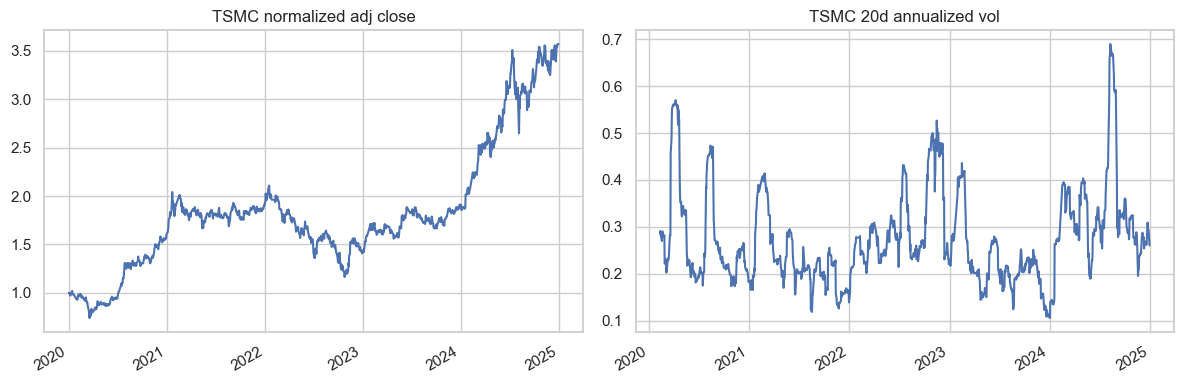

In [8]:
# Quick visual: TSMC normalized price
tsmc = clean.query("ticker == '2330.TW'").set_index("date")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
(tsmc["adj_close"] / tsmc["adj_close"].iloc[0]).plot(ax=ax[0], title="TSMC normalized adj close")
tsmc["ret_1d"].rolling(20).std().mul(np.sqrt(252)).plot(
    ax=ax[1], title="TSMC 20d annualized vol"
)
for a in ax:
    a.set_xlabel("")
plt.tight_layout()

## 5. Persist raw panel

Save as Parquet (one file per ticker keeps things diff-friendly even if we eventually version data with DVC). For the exploratory phase a single combined Parquet is enough.

In [9]:
out_path = RAW_PRICE_DIR / "tw50_seed_2020_2024.parquet"
clean.to_parquet(out_path, index=False)
print("wrote", out_path, "-", out_path.stat().st_size, "bytes")

wrote /Users/user/dev/quant-news-sentiment/data/raw/prices/tw50_seed_2020_2024.parquet - 769535 bytes


## Next steps

- Replace seed list with full TW50 historical constituents (Phase 2 / 7).
- Move the download logic into `src/data_collection/price_loader.py`.
- Begin news scraping in `src/data_collection/news_scraper.py`.
- Proceed to `notebooks/02_sentiment_analysis.ipynb`.